# EvalRX: gemma-4-e2b on bbh_word_sorting (TPU)

[Open in Colab](https://colab.research.google.com/github/evalvitals/evalrx/blob/ruinan/examples/colab/tpu/word_sorting_repair.ipynb)

Select a **TPU** runtime. This notebook launches **Antigravity CLI (`agy`) inside the runtime** for analysis and repair-code generation. Add `GEMINI_API_KEY` to Colab Secrets and allow notebook access (or enter it when asked). The API key drives the agent; the model under diagnosis runs locally on the accelerator.

We freeze 128 benchmark questions with seed 0, split them into 64 EXPLORE and 64 CONFIRM cases, select a repair using EXPLORE only, and evaluate the frozen winner once on CONFIRM. The model weights stay unchanged: L1 changes prompts and L2 changes the inference procedure. Agent-written code must pass the framework's frozen-model control; solving the task directly in Python does not count as repairing the model. A positive result must be established by the saved execution, not assumed from the notebook title.

> The saved outputs of sections 3–6 come from an earlier execution at source revision `4fa8752973b4` on TPU v5 lite, Colab image `release-colab-external-images_20261002-060053_RC00`. The setup cells were later replaced by the self-contained environment; their earlier outputs were removed because they no longer match the code.

## 1. Install

EvalRX runs in its own environment: a Python 3.12 interpreter and the exact package versions in `tools/colab/lock/tpu.txt`, installed to `/content/evalrx-env`. The notebook kernel's Python is left unchanged, so this cell gives the same environment on an updated Colab image or a Google-internal Colab runtime. Setup checks the network endpoints it needs first and names the variable that redirects any blocked one. Where GitHub or PyPI are unreachable, set `EVALRX_BUNDLE` to an offline bundle built with `tools/colab/build_bundle.sh`; see [the Colab README](https://github.com/evalvitals/evalrx/blob/ruinan/examples/colab/README.md).

In [ ]:
import os, subprocess, sys, json, shutil, tarfile, tempfile, urllib.request
from pathlib import Path
ACCEL = 'tpu'
# Pinned source revision. Change only to run newer EvalRX code.
EVALRX_REF = os.environ.get('EVALRX_REF', '63933a297316f6cbd72f1c15153b5bc3a200afb6')
# Offline bundle from tools/colab/build_bundle.sh: a local path (e.g. on Drive), https:// or gs:// URL.
# Set it where GitHub/PyPI are unreachable; then nothing else is downloaded during setup.
EVALRX_BUNDLE = os.environ.get('EVALRX_BUNDLE', '')
base = Path('/content') if Path('/content').is_dir() else Path.home()
repo = Path(os.environ.get('EVALRX_REPO', base / 'evalrx'))
env = Path(os.environ.setdefault('EVALRX_ENV', str(base / 'evalrx-env')))
os.environ.setdefault('EVALRX_DEMO_ROOT', str(base / 'evalrx_examples'))
os.environ.update(OMP_NUM_THREADS='2', PYTHONUNBUFFERED='1', TF_CPP_MIN_LOG_LEVEL='2',
                  MALLOC_ARENA_MAX='2', MALLOC_TRIM_THRESHOLD_='0')
def run_visible(command):
    with subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True) as process:
        for line in process.stdout:
            print(line, end='', flush=True)
        if process.wait():
            raise subprocess.CalledProcessError(process.returncode, command)
if not repo.exists() and EVALRX_BUNDLE:
    bundle = EVALRX_BUNDLE
    if bundle.startswith(('gs://', 'http://', 'https://')):
        bundle = str(Path(tempfile.mkdtemp()) / Path(EVALRX_BUNDLE).name)
        if EVALRX_BUNDLE.startswith('gs://'):
            tool = ['gcloud', 'storage', 'cp'] if shutil.which('gcloud') else ['gsutil', 'cp']
            run_visible(tool + [EVALRX_BUNDLE, bundle])
        else:
            urllib.request.urlretrieve(EVALRX_BUNDLE, bundle)
    unpack = Path(tempfile.mkdtemp(dir=repo.parent))
    with tarfile.open(bundle) as archive:
        archive.extractall(unpack, **({'filter': 'data'} if hasattr(tarfile, 'data_filter') else {}))
    (unpack / 'evalrx').rename(repo)
elif not repo.exists():
    run_visible(['git', 'init', '-q', str(repo)])
    run_visible(['git', '-C', str(repo), 'fetch', '-q', '--depth', '1',
                 'https://github.com/evalvitals/evalrx.git', EVALRX_REF])
    run_visible(['git', '-C', str(repo), 'checkout', '-q', 'FETCH_HEAD'])
# EvalRX gets its own Python 3.12 and locked packages in EVALRX_ENV; this kernel's
# Python is not modified, so Colab image updates do not change the environment.
run_visible(['bash', str(repo / 'tools/colab/bootstrap.sh'), ACCEL])
if (repo / '.bundle/data').is_dir():  # datasets frozen into the bundle
    shutil.copytree(repo / '.bundle/data', Path(os.environ['EVALRX_DEMO_ROOT']) / 'data', dirs_exist_ok=True)
os.environ['PATH'] = f"{env / 'bin'}:{os.environ['PATH']}"
os.chdir(repo)


## 2. Verify the TPU and launch agy

The agent must create and execute a Python file before the benchmark starts. Its transcript stays in this notebook.

In [ ]:
run_visible([str(env / 'bin/python'), '-c', "import jax; assert jax.default_backend() == 'tpu'; print([(str(d), d.device_kind) for d in jax.devices()])"])
commit = repo / '.bundle/COMMIT'
git_head = subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=repo, capture_output=True, text=True)
print('Source revision:', commit.read_text().strip() if commit.exists() else
      git_head.stdout.strip() if git_head.returncode == 0 else 'unknown (no git metadata)')
print('Runtime:', os.environ.get('COLAB_RELEASE_TAG', 'non-Colab validation environment'))
if not os.environ.get('GEMINI_API_KEY'):
    try:
        from google.colab import userdata
        os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')
    except Exception:
        import getpass
        os.environ['GEMINI_API_KEY'] = getpass.getpass('Gemini API key: ')
assert os.environ['GEMINI_API_KEY']
agent_dir = Path(os.environ['EVALRX_DEMO_ROOT']) / 'agent_check'
# The agent runs from the EvalRX environment, like every later EvalRX step.
run_visible([str(env / 'bin/python'), '-c', f"""
from pathlib import Path
from evalrx.agent_runtime.providers.antigravity import AntigravityAgent
agent_dir = Path({str(agent_dir)!r})
agent = AntigravityAgent(binary_path={str(env / 'bin/agy')!r}, model='gemini-3.8-flash-low',
                         timeout_sec=180, extra_args=['--output-format', 'stream-json'])
result = agent.run('Create agent_check.py that prints AGENT_READY. Run it with Python and report its output. Work only in this directory.', agent_dir)
print('Agent:', result.provider_name)
print(result.raw_output)
assert not result.error, result.error
assert (agent_dir / 'agent_check.py').exists()
print((agent_dir / 'agent_check.py').read_text())
"""])
run_visible([str(env / 'bin/python'), str(agent_dir / 'agent_check.py')])


## 3. Run the complete EvalRX workflow

The command runs baseline evaluation, M1 probes, agent-written exploratory analysis, M2 statistics, M3 hypotheses, M4 tests and M5 repair search. `--skip-surgery` omits the separate surgery experiments; M5 repair still runs. Eight EXPLORE cases per analyzer bound the demonstration's probing cost; all 128 cases receive baseline evaluation, and all 64 CONFIRM cases are reserved for the frozen candidate.

The same 512-token generation budget applies to the baseline; repairs may request more tokens and their extra computation is recorded. This is an inference-repair demonstration, not a claim that the underlying weights improved.


In [3]:
%%bash
set -euo pipefail
"$EVALRX_ENV/bin/evalrx" run \
  --modality llm --model gemma-4-e2b --dataset bbh_word_sorting \
  --backend jax_local --device tpu --dtype bfloat16 \
  --limit 128 --download-limit 128 --seed 0 \
  --max-new-tokens 512 --temperature 0 --analyzer-max-cases 8 \
  --judge-provider agy --judge-model gemini-3.8-flash-low \
  --fix-tier L2 --fix-repair-rounds 2 --fix-validation-cases 64 \
  --allow-codegen --explore --m2-codegen --skip-surgery \
  --data-dir "$EVALRX_DEMO_ROOT/data" --run-dir "$EVALRX_DEMO_ROOT/runs" \
  --run-tag tpu_notebook


[model] Gemma 4 E2B-it, spec gemma-4-e2b-it = google/gemma-4-E2B-it; backend=jax_local; benchmark=bbh_word_sorting; n=128
judge: agy model=gemini-3.8-flash-low effort=high
[model] weights loaded in 32s (attn_impl=None); generation={'max_new_tokens': 512, 'do_sample': False}
[device] tpu: TPU_0(process=0,(0,0,0,0)) (TPU v5 lite)
Baseline: PASS=54, FAIL=74, UNKNOWN=0, accuracy=0.422 (533s, 4.2s/case)

VLDiagnoseLoop  model=gemma-4-e2b  max_cycles=1
RUN loop        ·········· starting · model=JaxLocalModel(key='gemma-4-e2b-it', adapter=GemmaJaxAdapter, loaded) · n_cases=64
M1  probe       ········· cycle 0 · 8 analyzers run (928.9s)
M2  explore     ······· cycle 0 · explore report ready (79.7s)
M2  explore     ······· cycle 0 · 1 finding(s) · severity=medium · 1 figure(s) (21.5s)
M3  diagnose    ······ cycle 0 · 3 falsifiable hypotheses proposed (7.5s)
M4  verify      ········ cycle 0 · ✗ Generation budget exhaustion truncates the model's scratchpad reaso... — inconclusive (5.3s)
M4  veri

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
E1005 21:38:57.736862   28027 google_auth_provider.cc:188] Could not find the credentials file in the standard gcloud location [/content/.config/application_default_credentials.json]. You may specify a credentials file using $GOOGLE_APPLICATION_CREDENTIALS, or to use Google application default credentials, run: gcloud auth application-default login
/usr/lib/python3.13/subprocess.py:1922: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


## 4. Read the measured result

The benchmark uses its registered exact-answer grader. EXPLORE chooses the candidate; only an independent CONFIRM result can establish a successful repair.

Baseline: 54/128 (42.2%)
Verified hypotheses: 0
Frozen candidate: expanded_verification_consensus


,split,n,baseline_correct,candidate_correct,repaired_cases,regressed_cases,e_value,required_e_value,verdict,validated_fix
0,CONFIRM,64,27,37,13,3,6.884034,20.0,partial,False


<IPython.core.display.JSON object>

No statistically confirmed accuracy repair.


### EXPLORE candidates (selection only)

,name,headline,tier,n_pairs,n_fixed,n_broken,effect,e_value,coverage,verdict
0,bucket_by_first_letter,Tells the model to group words by their starti...,L1,64,6,7,-0.015625,0.340992,1.0,unsafe
1,direct_alphabetical_listing,Instructs the model to write out the full alph...,L1,64,4,3,0.015625,0.457143,1.0,partial
2,pairwise_selection_sort,Directs the model to repeatedly find and cross...,L1,64,13,4,0.140625,3.059570,1.0,partial
3,divide_and_conquer_halves,Splits the word list into an A-M group and an ...,L1,64,0,9,-0.140625,51.200000,1.0,regressed
4,adjacent_pair_verification,Directs the model to check every neighboring p...,L1,64,4,4,0.000000,0.406349,1.0,no_effect
5,explicit_prefix_disambiguation,Asks the model to write out the first three le...,L1,64,1,12,-0.171875,45.010989,1.0,regressed
6,token_expansion_self_refine,Gives the model twice as much writing space an...,L2,64,11,1,0.156250,26.256410,1.0,fixed
7,expanded_verification_consensus,Raises the token limit so lists are never cut ...,L2,64,14,2,0.187500,32.125490,1.0,fixed
8,subproblem_least_to_most,Breaks the sorting task into smaller sequentia...,L2,64,11,5,0.093750,0.882568,1.0,partial
9,self_consistency_5,Asks the same question five times and keeps th...,L2,64,3,3,0.000000,0.457143,1.0,no_effect


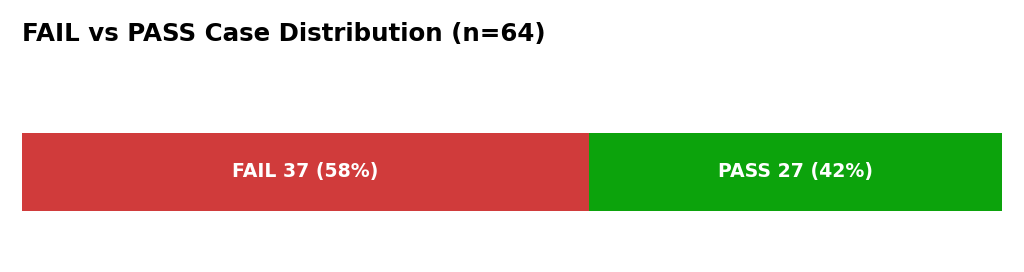

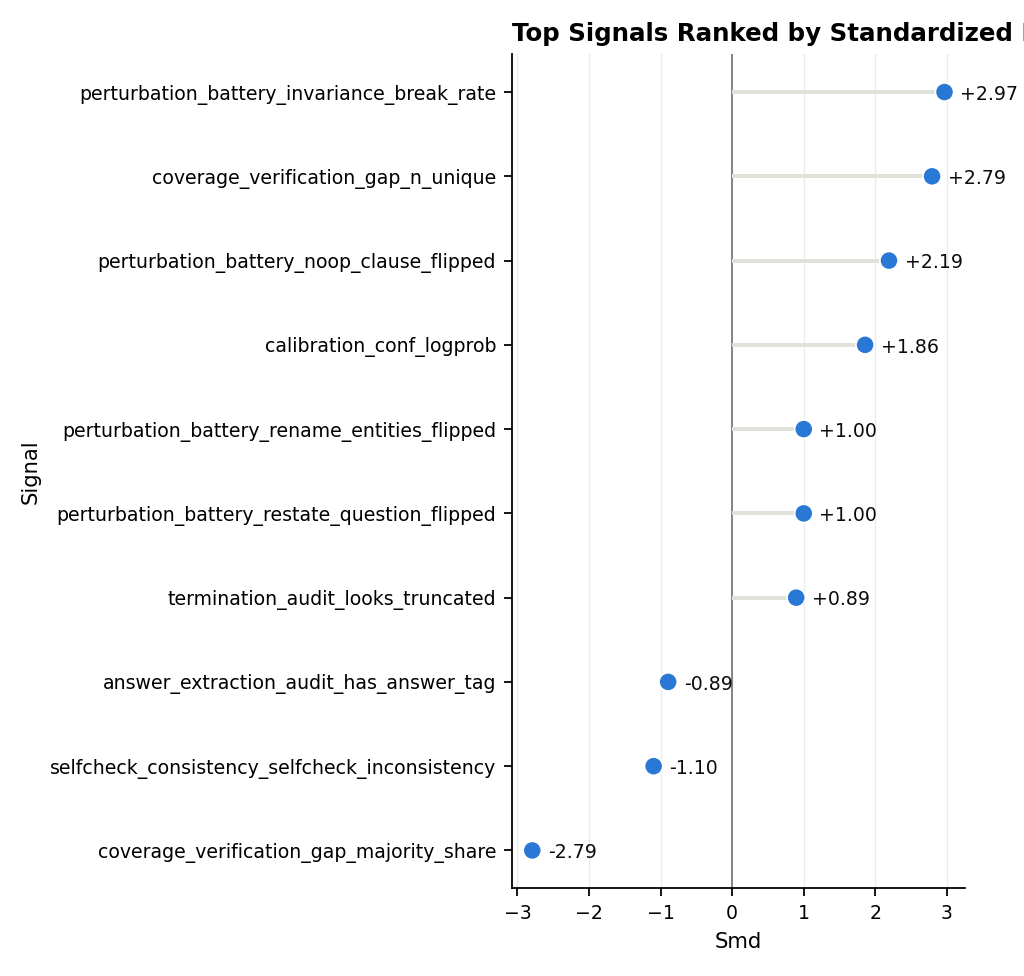

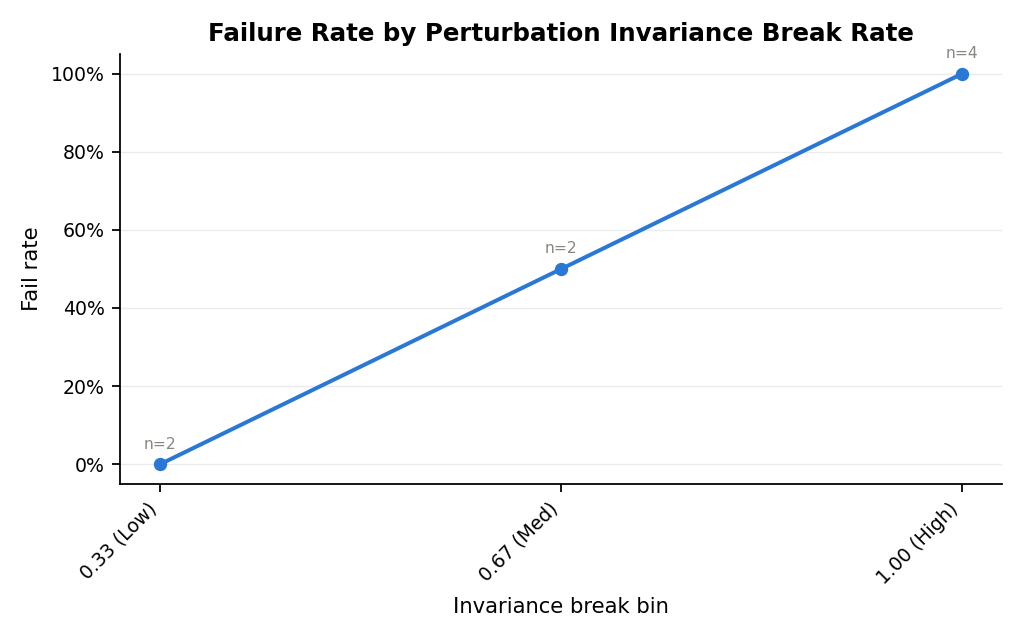

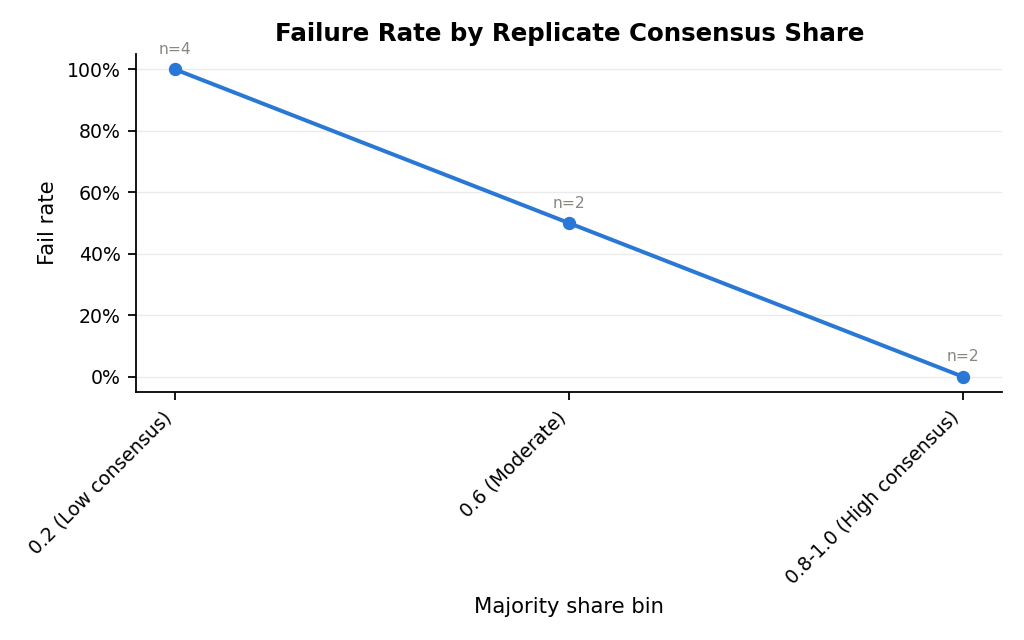

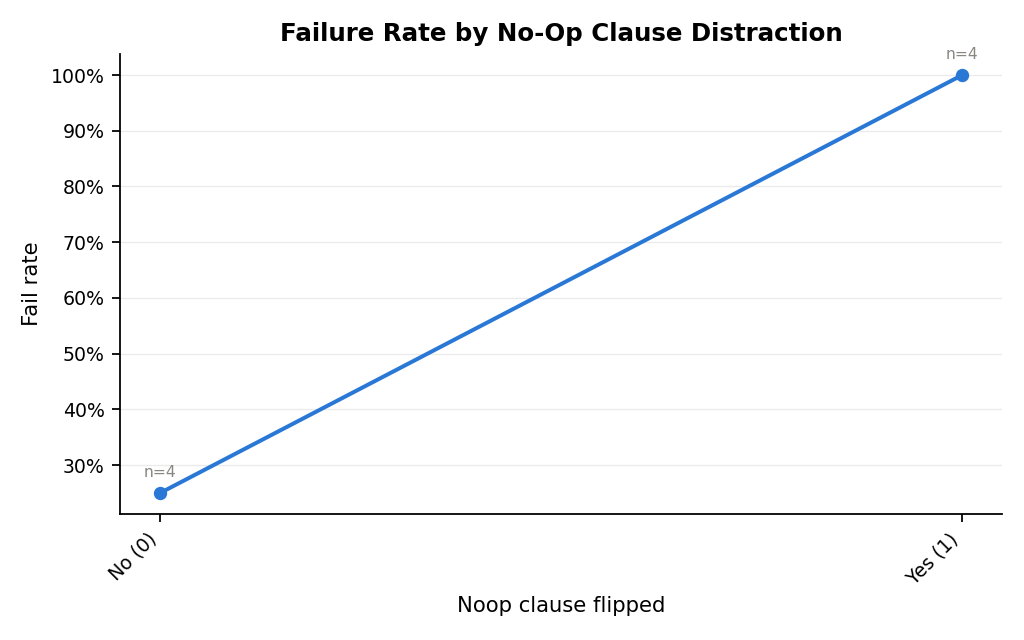

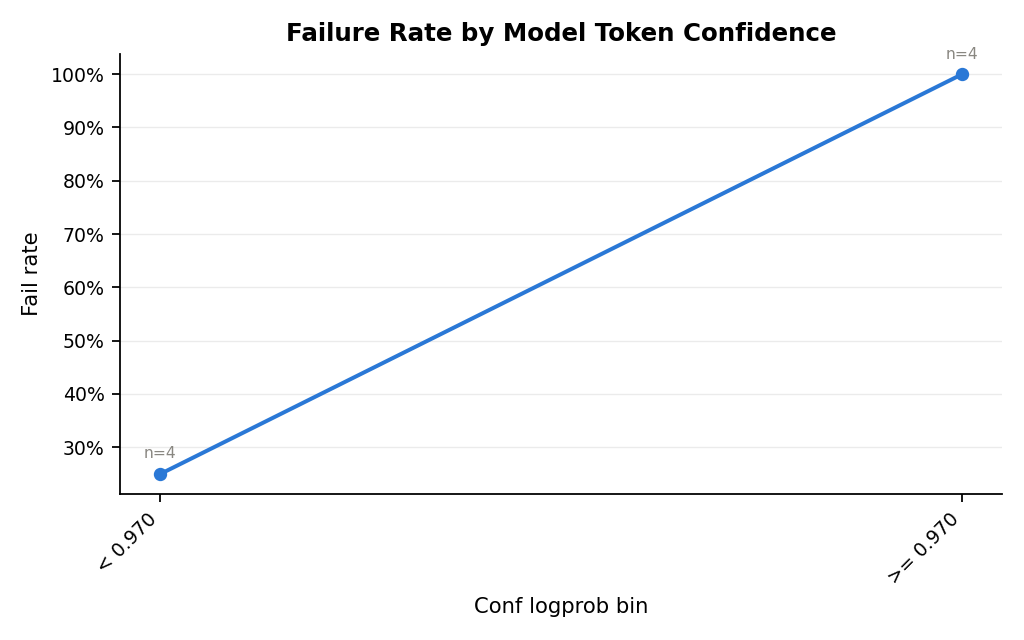

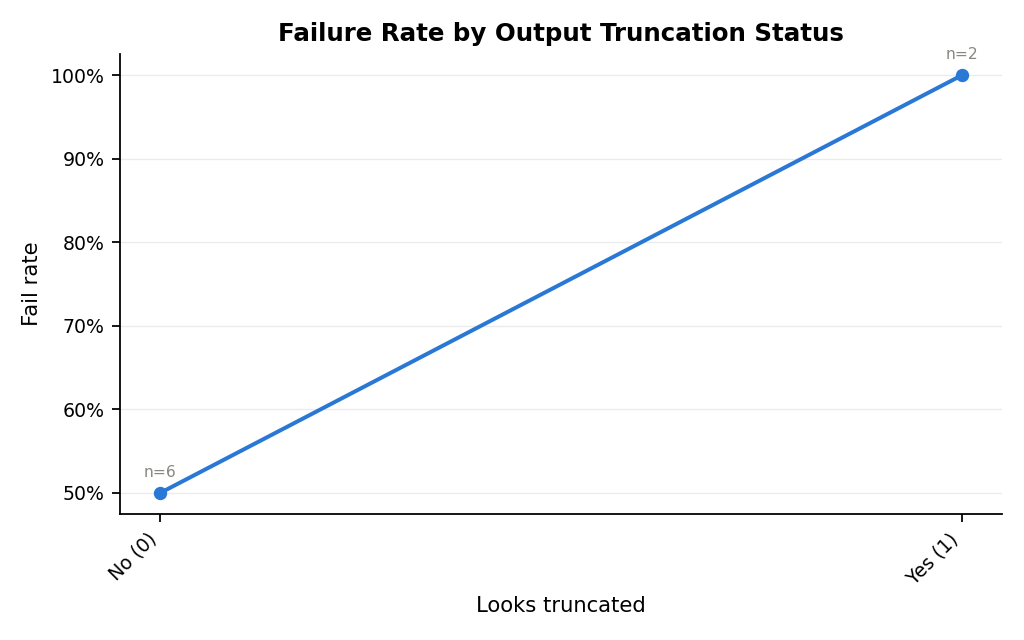

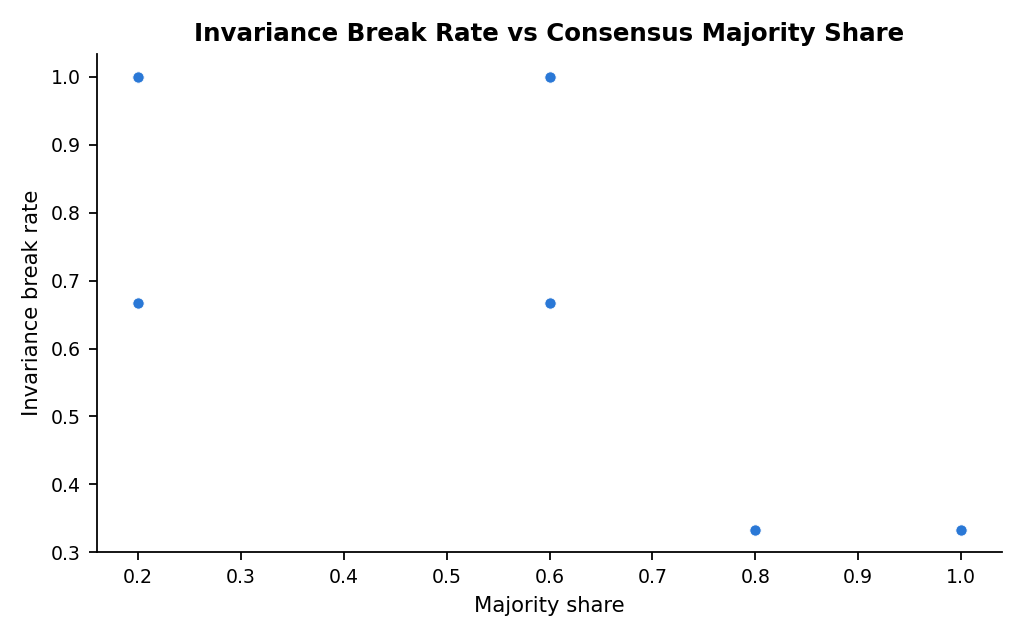

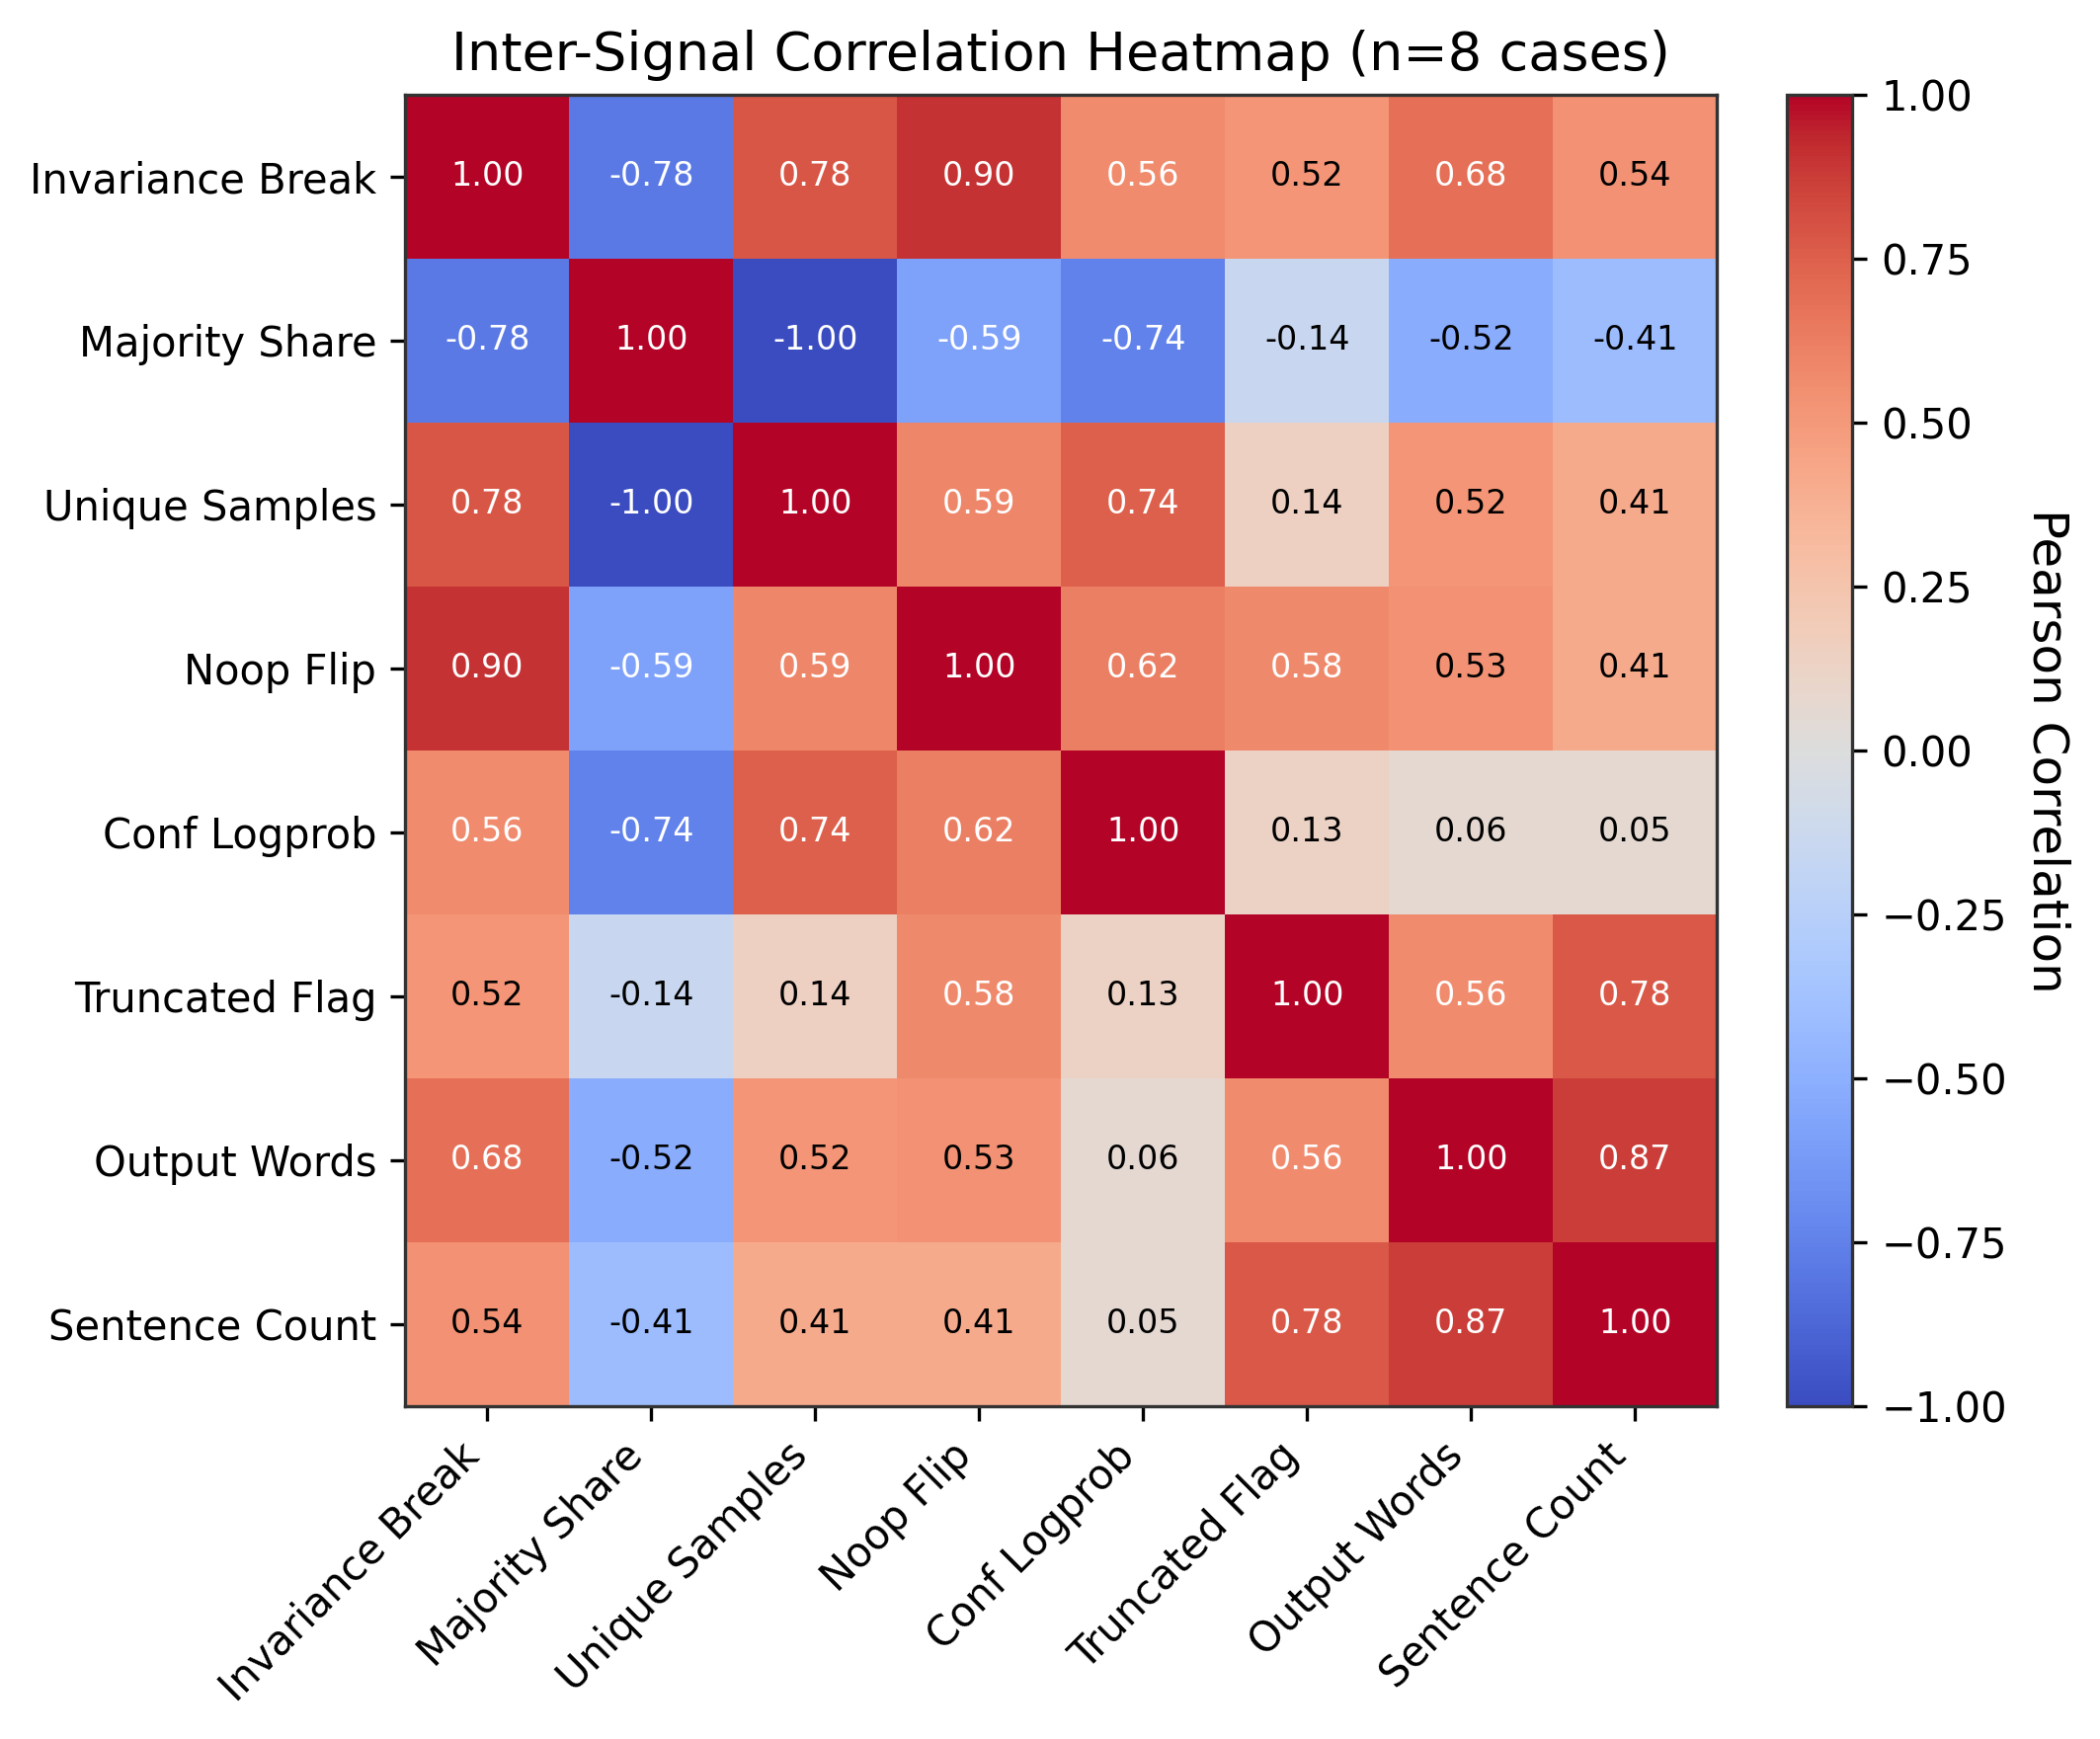

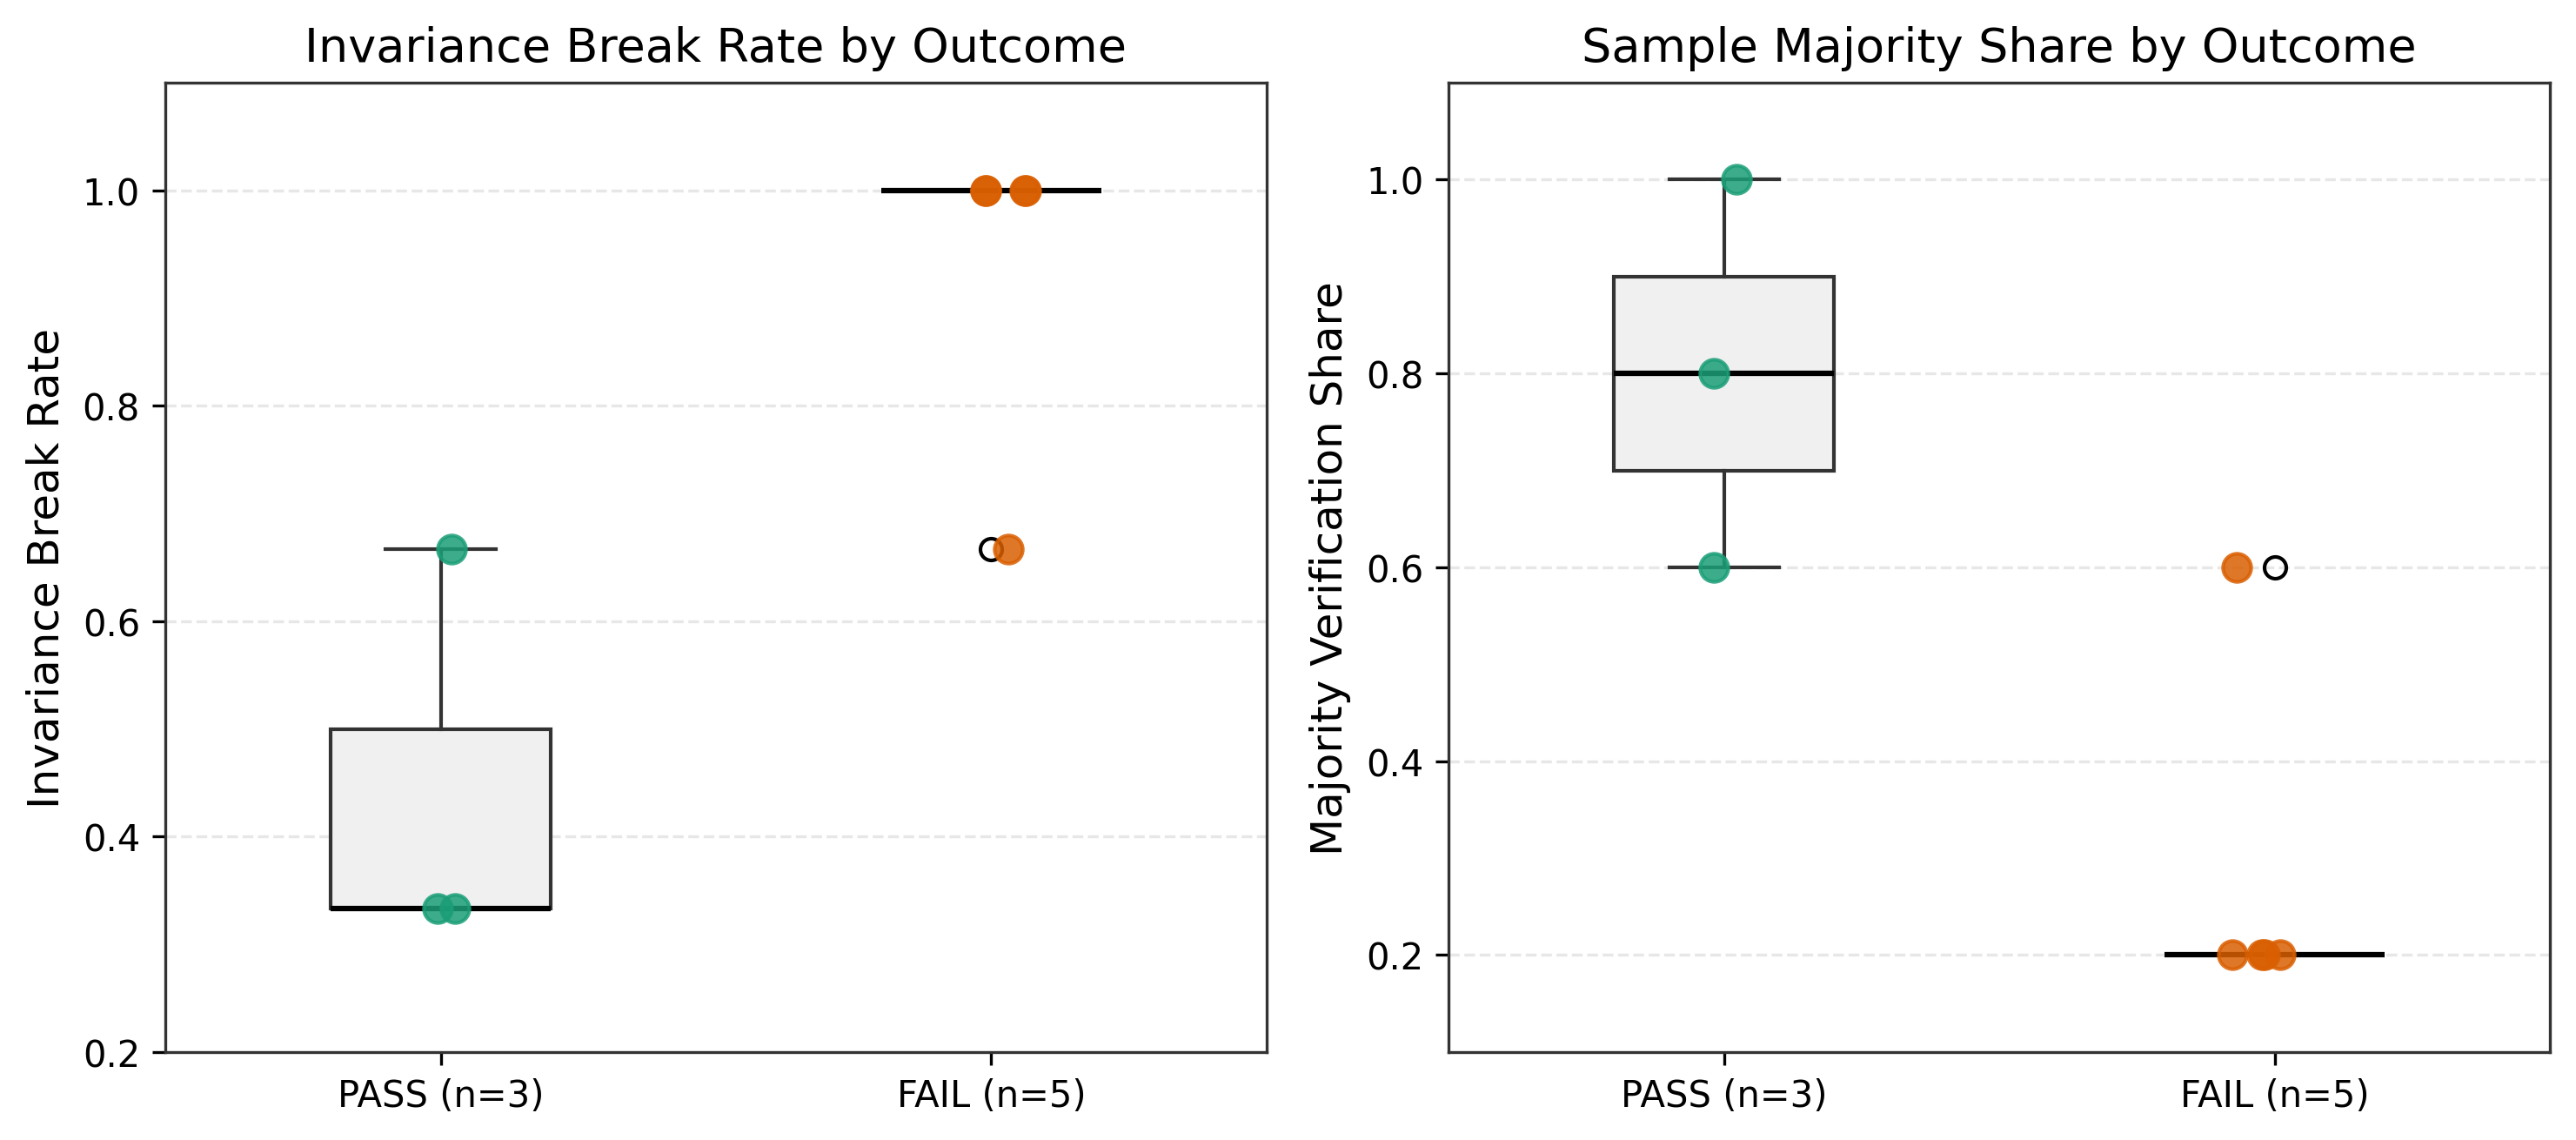

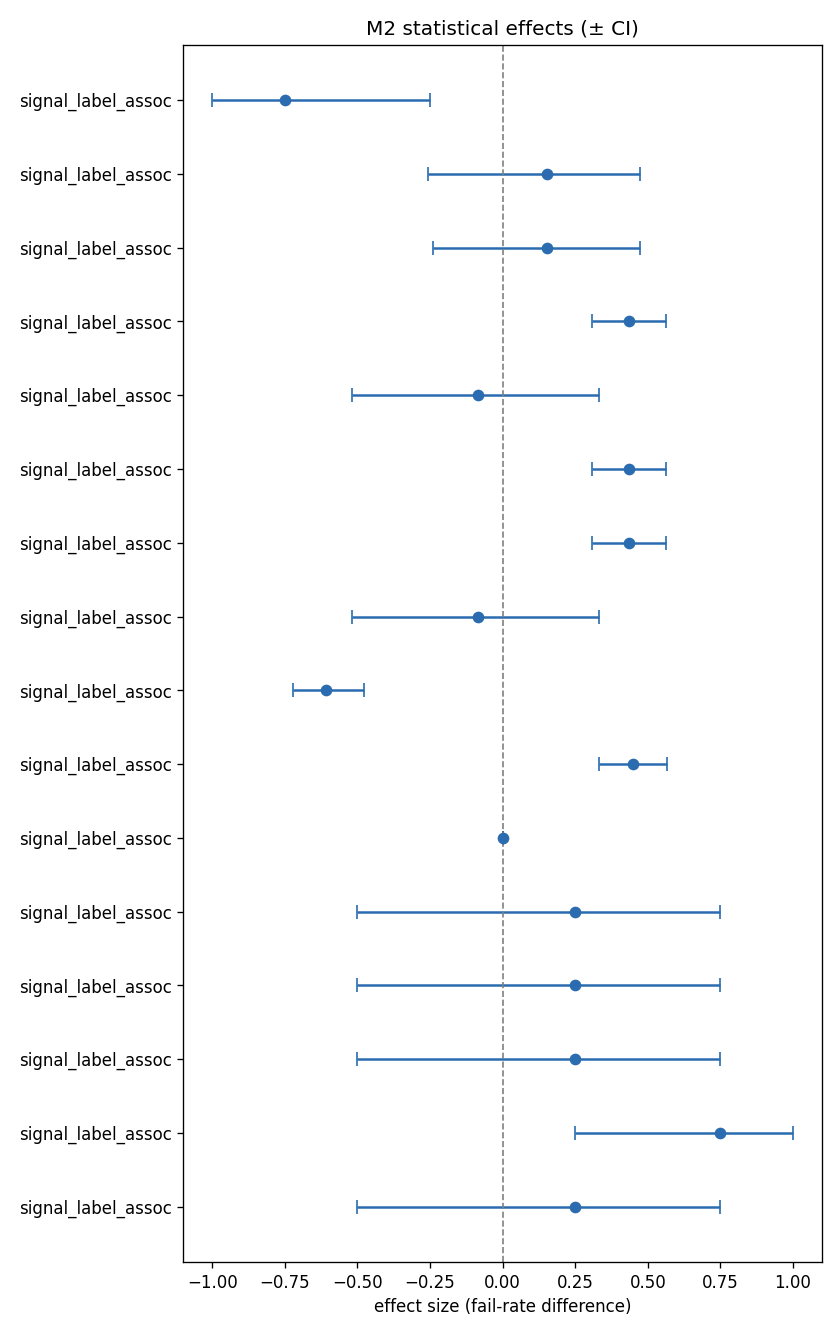

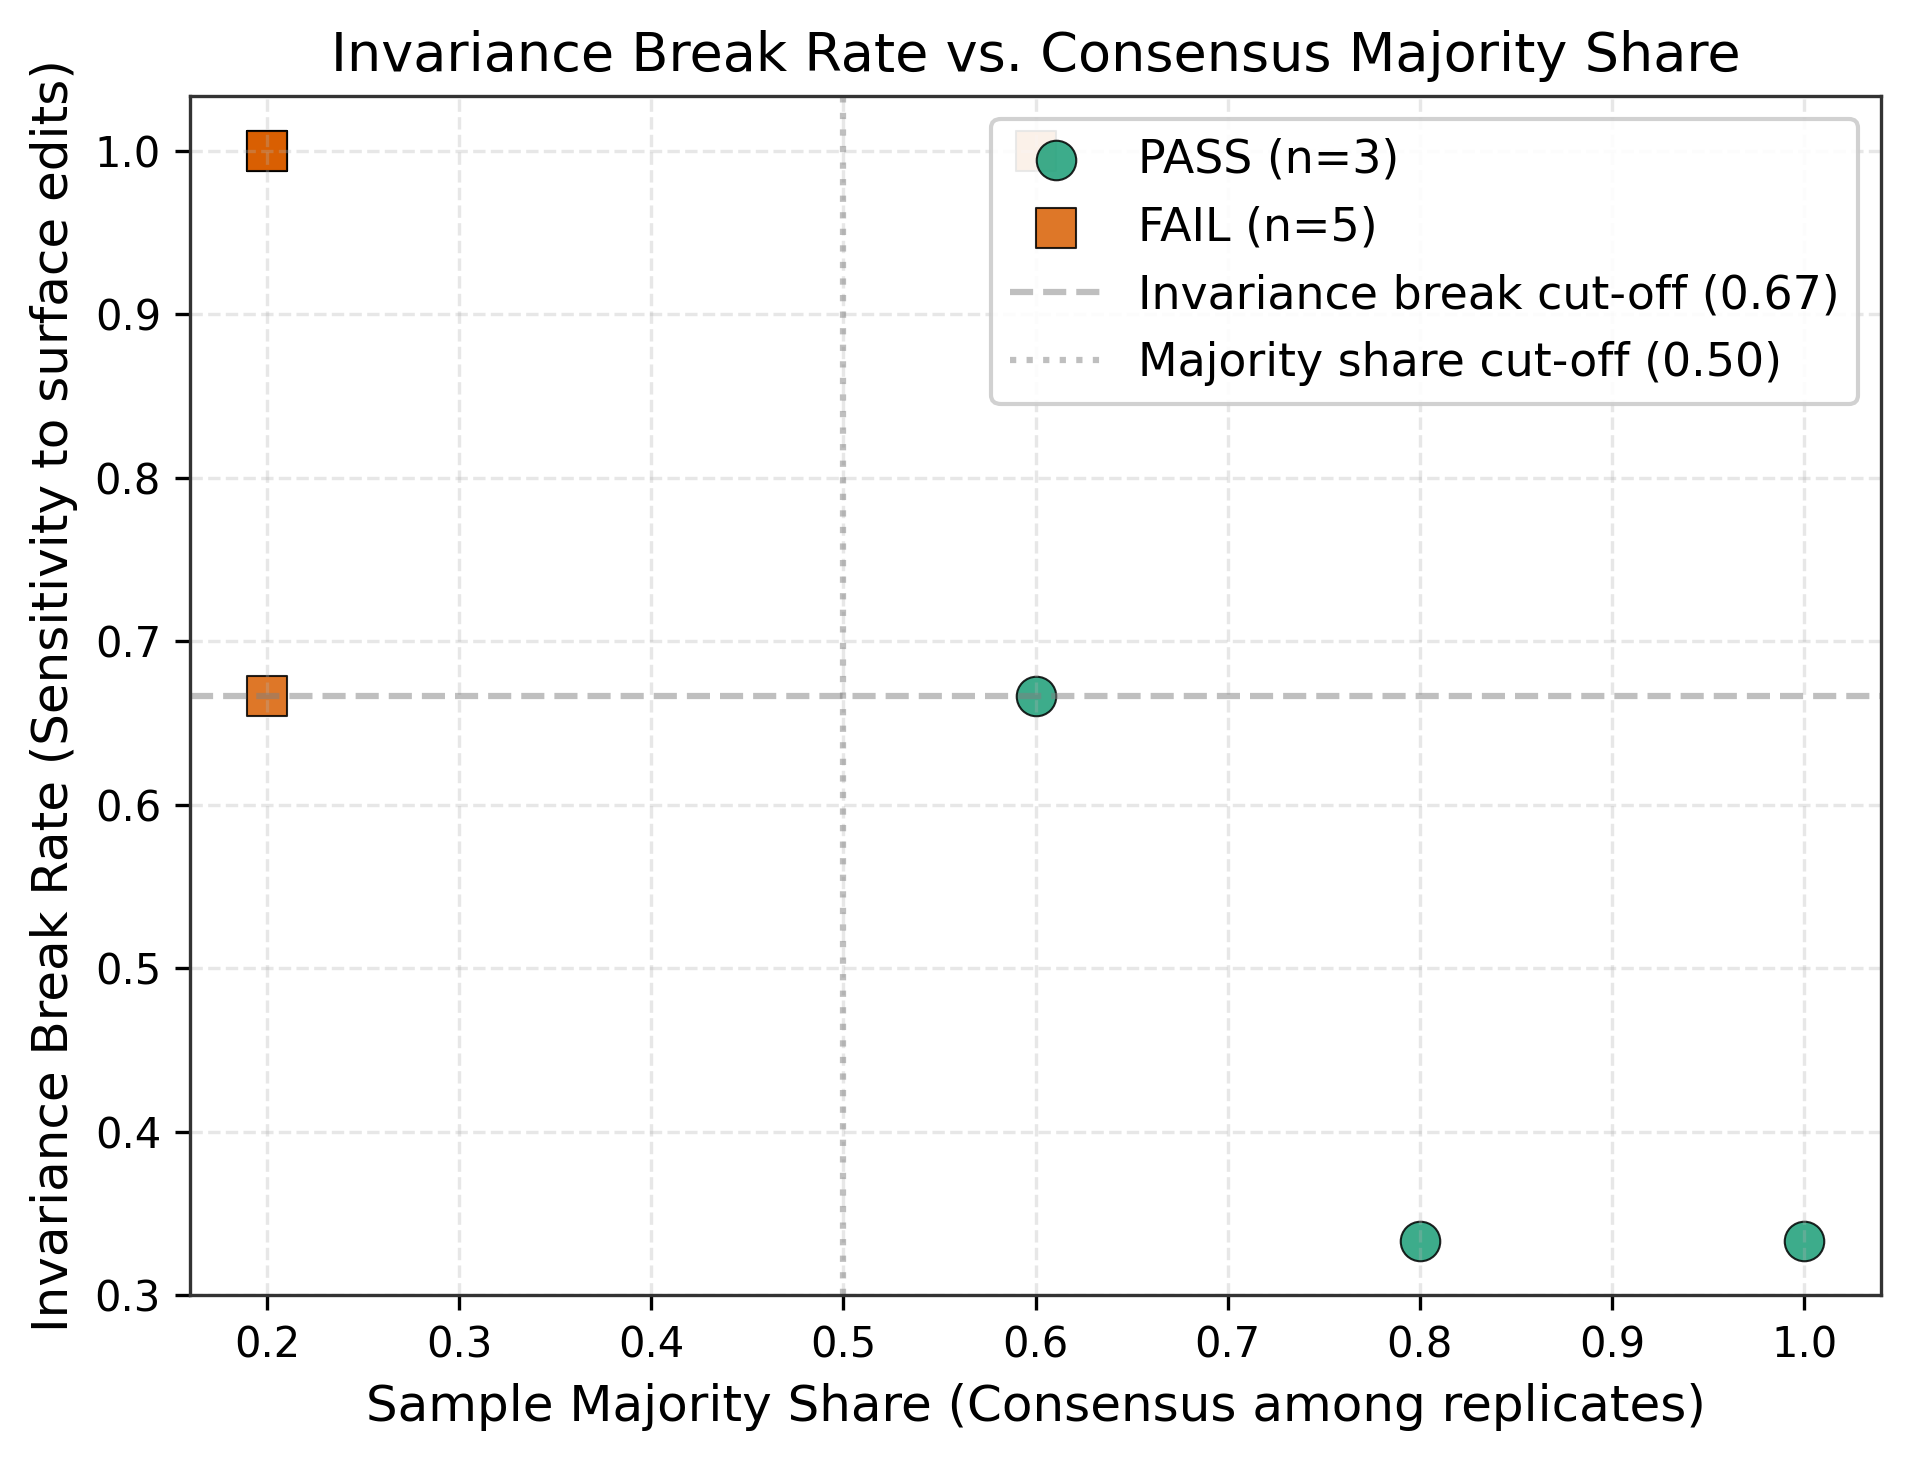

In [4]:
import json
import pandas as pd
from IPython.display import display, Markdown, Image, JSON

run_dir = Path(os.environ['EVALRX_DEMO_ROOT']) / 'runs/gemma-4-e2b/bbh_word_sorting.tpu_notebook'
read_json = lambda p: json.loads(p.read_text())
baseline = read_json(run_dir / 'baseline.json')
summary = read_json(run_dir / 'summary.json')
stages = {stage: read_json(run_dir / 'logs' / stage / 'log.json')
          for stage in ['M1', 'M2', 'M3', 'M4', 'M5']
          if (run_dir / 'logs' / stage / 'log.json').exists()}
fix = (stages.get('M5', {}).get('fix') or [{}])[-1]
attempts = fix.get('attempted', [])
print(f"Baseline: {baseline['n_pass']}/{baseline['n']} ({baseline['accuracy']:.1%})")
print(f"Verified hypotheses: {summary['n_verified']}")
print('Frozen candidate:', fix.get('selected_on_explore') or 'none')
if attempts:
    final = attempts[0]
    display(pd.DataFrame([{
        'split': 'CONFIRM', 'n': final['n_pairs'],
        'baseline_correct': final['n_baseline_correct'],
        'candidate_correct': final['n_candidate_correct'],
        'repaired_cases': final['n_fixed'], 'regressed_cases': final['n_broken'],
        'e_value': final['e_value'], 'required_e_value': final['e_threshold'],
        'verdict': final['verdict'], 'validated_fix': final['fixed'],
    }]))
    display(JSON(final['payload']))
    print('Accuracy repair validated.' if final['fixed'] else 'No statistically confirmed accuracy repair.')
else:
    print('No candidate selected for CONFIRM; no validated accuracy repair.')
if fix.get('selection_attempted'):
    display(Markdown('### EXPLORE candidates (selection only)'))
    display(pd.DataFrame(fix['selection_attempted']))
for image in sorted((run_dir / 'logs/M2/artifacts').glob('*.png')):
    display(Image(filename=str(image)))


## 5. Inspect every answer

These tables are generated from this run and saved in the notebook output, so a reader does not need separate result files.

In [5]:
manifest = read_json(Path(os.environ['EVALRX_DEMO_ROOT']) / 'data/bbh_word_sorting/manifest.json')
questions = {row['id']: row['prompt'] for row in manifest}
rows = [{**row, 'question': questions[row['id']]} for row in baseline['cases']]
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(pd.DataFrame(rows)[['id', 'question', 'expected', 'observed', 'label']])
    if attempts:
        before = {row['id']: row for row in baseline['cases']}
        display(pd.DataFrame([{
            'id': cid, 'expected': before[cid]['expected'],
            'baseline': before[cid]['observed'], 'candidate': answer,
            'repaired': cid in final['fixed_cases'], 'regressed': cid in final['broken_cases'],
        } for cid, answer in final['outputs'].items()]))


,id,question,expected,observed,label
0,bbh_word_sorting-0000,Sort the following words alphabetically: List: alleviate duopoly mattress gland benelux townsmen buoyant klaxon hardbound tomography felice gunk\n\nSolve the problem. Put the final answer on its own last line as 'Answer: <answer>'.,alleviate benelux buoyant duopoly felice gland gunk hardbound klaxon mattress tomography townsmen,"Here are the words to sort alphabetically: alleviate, duopoly, mattress, gland, benelux, townsmen, buoyant, klaxon, hardbound, tomography, felice, gunk.\n\n1. **alleviate**\n2. **benelux**\n3. **buoyant**\n4. **duopoly**\n5. **felice**\n6. **gland**\n7. **hardbound**\n8. **klaxon**\n9. **mattress**\n10. **tomography**\n11. **townsmen**\n\nLet's re-sort them carefully:\n\n* **a**lleviate\n* **b**enelux, **b**uoyant (benelux before buoyant)\n* **d**uopoly\n* **f**elice\n* **g**land, **g**unk (gland before gunk)\n* **h**ardbound\n* **k**laxon\n* **m**attress\n* **t**omography, **t**ownsmen (tomography before townsmen)\n\n**Final Sorted List:**\n1. alleviate\n2. benelux\n3. buoyant\n4. duopoly\n5. felice\n6. gland\n7. gunk\n8. hardbound\n9. klaxon\n10. mattress\n11. tomography\n12. townsmen\n\nWait, let's re-check the 'g' words: gland, gunk. Gland comes before Gunk.\n\nLet's re-check the 'b' words: benelux, buoyant. Benelux comes before Buoyant.\n\nLet's re-check the 't' words: tomography, townsmen. Tomography comes before Townsmen.\n\n**Final Alphabetical Order:**\n1. alleviate\n2. benelux\n3. buoyant\n4. duopoly\n5. felice\n6. gland\n7. gunk\n8. hardbound\n9. klaxon\n10. mattress\n11. tomography\n12. townsmen\n\nAnswer: alleviate, benelux, buoyant, duopoly, felice, gland, gunk, hardbound, klaxon, mattress, tomography, townsmen",pass
1,bbh_word_sorting-0001,Sort the following words alphabetically: List: yuh edt cheddar oblivion from poignant pang\n\nSolve the problem. Put the final answer on its own last line as 'Answer: <answer>'.,cheddar edt from oblivion pang poignant yuh,"The given list of words is: yuh, edt, cheddar, oblivion, from, poignant, pang.\n\nWe need to sort these words alphabetically.\n\n1. **Compare the first letters:**\n - yuh (y)\n - edt (e)\n - cheddar (c)\n - oblivion (o)\n - from (f)\n - poignant (p)\n - pang (p)\n\n2. **Order based on the first letter:**\n - c (cheddar)\n - e (edt)\n - f (from)\n - o (oblivion)\n - p (poignant, pang)\n - y (yuh)\n\n3. **Sort the words starting with 'p':**\n - poignant\n - pang\n (Comparing the second letters: 'o' in poignant vs 'a' in pang. 'a' comes before 'o'.)\n So, the order is: pang, poignant.\n\n4. **Assemble the final sorted list:**\n - cheddar (c)\n - edt (e)\n - from (f)\n - oblivion (o)\n - pang (p)\n - poignant (p)\n - yuh (y)\n\nLet's re-check the 'p' words:\npang (p-a-n-g)\npoignant (p-o-i-g-n-a-n-t)\n'a' comes before 'o', so pang comes before poignant.\n\nFinal sorted order: cheddar, edt, from, oblivion, pang, poignant, yuh.\n\nAnswer: cheddar, edt, from, oblivion, pang, poignant, yuh",pass
2,bbh_word_sorting-0002,Sort the following words alphabetically: List: intercept tamp geopolitic loci newsmen umber credit atmospheric lunge siren swart chess\n\nSolve the problem. Put the final answer on its own last line as 'Answer: <answer>'.,atmospheric chess credit geopolitic intercept loci lunge newsmen siren swart tamp umber,"Here are the words to sort: intercept, tamp, geopolitic, loci, newsmen, umber, credit, atmospheric, lunge, siren, swart, chess.\n\nLet's sort them alphabetically:\n\n1. atmospheric\n2. chess\n3. credit\n4. geopolitic\n5. intercept\n6. loci\n7. lunge\n8. newsmen\n9. siren\n10. swart\n11. tamp\n12. umber\n\nLet's re-check the sorting carefully:\n\n* **a**tmospheric\n* **c**hess\n* **c**redit\n* **g**eopolitic\n* **i**ntercept\n* **l**oci\n* **l**unge\n* **n**ewsmens\n* **s**iren\n* **s**wart\n* **t**amp\n* **u**mber\n\nComparing 'loci' and 'lunge': 'loci' comes before 'lunge'.\n\nComparing 'siren' and 'swart': 'siren' comes before 'swart'.\n\nThe correct alphabeti

,id,expected,baseline,candidate,repaired,regressed
0,bbh_word_sorting-0104,avalanche befriend berniece bong bremsstrahlung dactylic flick gilbertson goff hereafter hoe housekeep hurry lanka metazoan posterior showroom,"Here are the words to sort alphabetically:\nberniece, bremsstrahlung, hoe, avalanche, showroom, goff, dactylic, befriend, hurry, housekeep, lanka, gilbertson, posterior, flick, bong, hereafter, metazoan\n\nLet's sort them:\n\n1. avalanche\n2. befriend\n3. berniece\n4. bong\n5. bremsstrahlung\n6. dactylic\n7. flick\n8. goff\n9. hereafter\n10. housekeep\n11. hurry\n12. gilbertson\n13. lanka\n14. metazoan\n15. posterior\n16. showroom\n\nLet's re-check the sorting carefully, especially for words starting with similar letters:\n\n* **a**: avalanche\n* **b**: befriend, berniece, bong, bremsstrahlung\n * befriend\n * berniece\n * bong\n * bremsstrahlung (b-r-e-s...)\n* **d**: dactylic\n* **f**: flick\n* **g**: goff, gilbertson\n * goff\n * gilbertson\n* **h**: hereafter, housekeep, hurry\n * hereafter\n * housekeep\n * hurry\n* **l**: lanka\n* **m**: metazoan\n* **p**: posterior\n* **s**: showroom\n\nLet's perform a strict alphabetical sort:\n\n1. avalanche (A)\n2. befriend (B)\n3. berniece (B)\n4. bong (B)\n5. bremsstrahlung (B)\n * Comparing B words: befriend, berniece, bong, bremsstrahlung.\n * befriend (bef...)\n * berniece (ber...)\n * bong (bon...)\n * bremsstrahlung (bre...)\n * Order: befriend, berniece, bong, bremsstrahlung (b-e-f, b-e-r, b-o-n, b-r-e) - Wait, 'berniece' comes before 'bong' and 'bremsstrahlung'. Let's check again:\n * befriend\n * berniece\n * bong\n * bremsstrahlung\n * Correct order for B words: befriend, berniece, bong, bremsstrahlung. (b-e-f, b-e-r, b-o, b-r) -","Answer: avalanche, befriend, berniece, bremsstrahlung, bong, dactylic, flick, gilbertson, goff, hereafter, hoe, housekeep, hurry, lanka, metazoan, posterior, showroom",False,False
1,bbh_word_sorting-0019,broadcast cortland diffusible galvanometer gross gujarati incestuous larynx nomograph pewter scout sketchbook stag transition,"Here are the words sorted alphabetically:\n\n1. broadcast\n2. cortland\n3. diffusible\n4. galvanometer\n5. gross\n6. gujarati\n7. incestuous\n8. larynx\n9. nomograph\n10. pewter\n11. scout\n12. sketchbook\n13. stag\n14. transition\n\nLet's re-sort them carefully:\n\n* **b**roadcast\n* **c**ortland\n* **d**iffusible\n* **g**alvometer\n* **g**ross\n* **g**ujarati\n* **i**ncestuous\n* **l**arynx\n* **n**omograph\n* **p**ewter\n* **s**cout\n* **s**teag (Wait, 'stag' comes before 'sketchbook' if we look at the second letter, but alphabetically 'stag' comes before 'sketchbook' if we compare 't' vs 'k'. Let's re-examine the list.)\n\nOriginal List: pewter gross gujarati cortland diffusible nomograph stag broadcast galvanometer transition incestuous sketchbook scout larynx\n\n1. broadcast\n2. cortland\n3. diffusible\n4. galvanometer\n5. gross\n6. gujarati\n7. incestuous\n8. larynx\n9. nomograph\n10. pewter\n11. scout\n12. sketchbook\n13. stag\n14. transition\n\nLet's perform a strict alphabetical sort:\n\n1. broadcast (b)\n2. cortland (c)\n3. diffusible (d)\n4. galvanometer (g)\n5. gross (g)\n6. gujarati (g)\n7. incestuous (i)\n8. larynx (l)\n9. nomograph (n)\n10. pewter (p)\n11. scout (s)\n12. sketchbook (s)\n13. stag (s)\n14. transition (t)\n\nSorting the 'g' words: galvanometer, gross, gujarati.\n* galvanometer\n* gross\n* gujarati\n\nSorting the 's' words: scout, sketchbook, stag.\n* sketchbook (sk)\n* scout (sc)\n* stag (st)\n* Therefore: sketchbook, scout, stag\n\nFinal sorted list:\n1. broadcast\n2. cortland\n","broadcast, cortland, diffusible, galvanometer, gross, gujarati, incestuous, larynx, nomograph, pewter, sketchbook, scout, stag, transition",False,False
2,bbh_word_sorting-0091,abutted agamemnon aquatic capacity casualty essex guinea hitachi hondo islamic loosen loquacious niece planet roadway solstice steed suspicion tibet,"Here are the words sorted alphabetically:\n\n1. abutted\n2. agamemnon\n3. aq

## 6. Full agent and stage records

The saved records include generated code, analysis, hypotheses, candidate selection and confirmation. Save the executed notebook to keep these results together.

In [6]:
display(JSON({'baseline': baseline, 'summary': summary, 'stages': stages}))
for source in sorted(run_dir.rglob('*.py')):
    print('\n---', source.relative_to(run_dir), '---')
    print(source.read_text())


<IPython.core.display.JSON object>